In [1]:
import gaiaDR4_pipeline as gp
from pathlib import Path
from tqdm import tqdm 
import os
import torch
torch.set_num_threads(1) 
torch.set_num_interop_threads(1)
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

In [13]:
cwd = Path(os.getcwd()) / "dr4_prerelease"

In [14]:
table = Table.read(cwd / "GAIA_DR4_PRERELEASE_EPOCH_ASTROMETRY_RAW.xml", format="votable")
df_data = table.to_pandas()

In [15]:
source_ids = [ 1457486023639239296,  3937211745905473024]

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

for source_id in tqdm(source_ids):
    t_binned, psi_binned, w_binned, sig_w_binned, pf_binned = gp.utils.extract_time_series(source_id, df_data)
    gp.grid.run_grid_search(cwd, source_id, t_binned, psi_binned, pf_binned, w_binned, sig_w_binned, 
                                  device=device, N_logP=300, N_ecc=10, N_phi=10, P_range=[10,1e4])

cpu


100%|██████████| 2/2 [00:13<00:00,  6.54s/it]


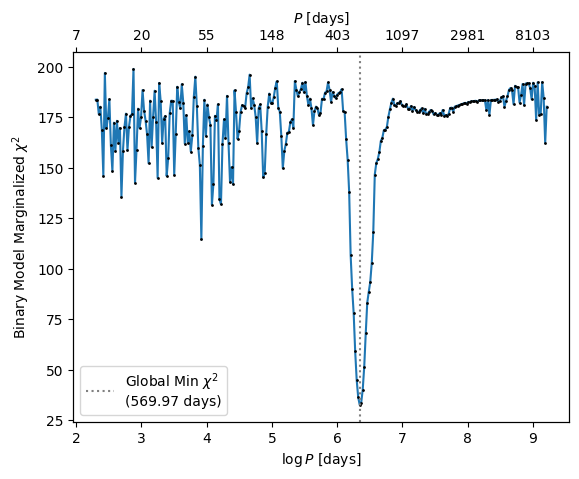

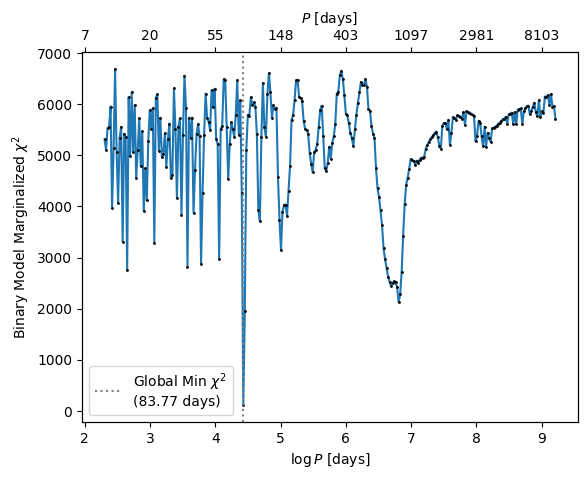

In [17]:
for source_id in source_ids:
    gp.plotting.plot_grid_search_chi2(cwd, source_id)
    plt.show()